In [ ]:
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/Data UAS Visdat/data')
data_path = BASE_DIR / 'multivariate_jateng.json'

print("Folder:", BASE_DIR)
print("File:", data_path)
print("Folder ada?:", BASE_DIR.exists())
print("File ada?:", data_path.exists())

if BASE_DIR.exists():
    print("\nIsi folder:")
    for f in BASE_DIR.iterdir():
        print("-", f.name)


Mounted at /content/drive
Folder: /content/drive/MyDrive/Data UAS Visdat/data
File: /content/drive/MyDrive/Data UAS Visdat/data/multivariate_jateng.json
Folder ada?: True
File ada?: True

Isi folder:
- multivariate_jateng.json
- hierarchy_jateng.json
- geospatial_national.json
- geospatial_national.js
- multivariate_jateng.js
- hierarchy_jateng.js


1. MEMUAT DATA MULTIVARIAT JAWA TENGAH
Dataset berhasil dimuat!
- Jumlah Wilayah Observasi: 35 Kabupaten/Kota
- Jumlah Variabel Analisis: 8 Variabel
- Tahun Acuan Utama       : 2025

Contoh 5 Baris Data Teratas:
       tpt   tpak        umk  pdrb_kapita  pengeluaran  angkatan_kerja   rls  \
3301  7.40  66.67  2640248.0      69736.0    1198865.0       1071270.0  7.65   
3302  6.26  69.87  2338410.0      42784.0    1417648.0       1024068.0  8.10   
3303  4.83  75.35  2338283.0      34427.0    1270469.0        612818.0  7.37   
3304  5.39  73.92  2170475.0      29366.0    1166949.0        615877.0  7.10   
3305  4.95  76.17  2259874.0      28999.0    1306234.0        853535.0  7.89   

      kepadatan  
3301      881.0  
3302     1341.0  
3303     1300.0  
3304      932.0  
3305     1073.0  

2. EVALUASI KUALITAS DATA & PREPROCESSING (SKEWNESS & OUTLIERS)
                      mean        std         min         50%         max  \
tpt                   4.41       1.46        2.16        

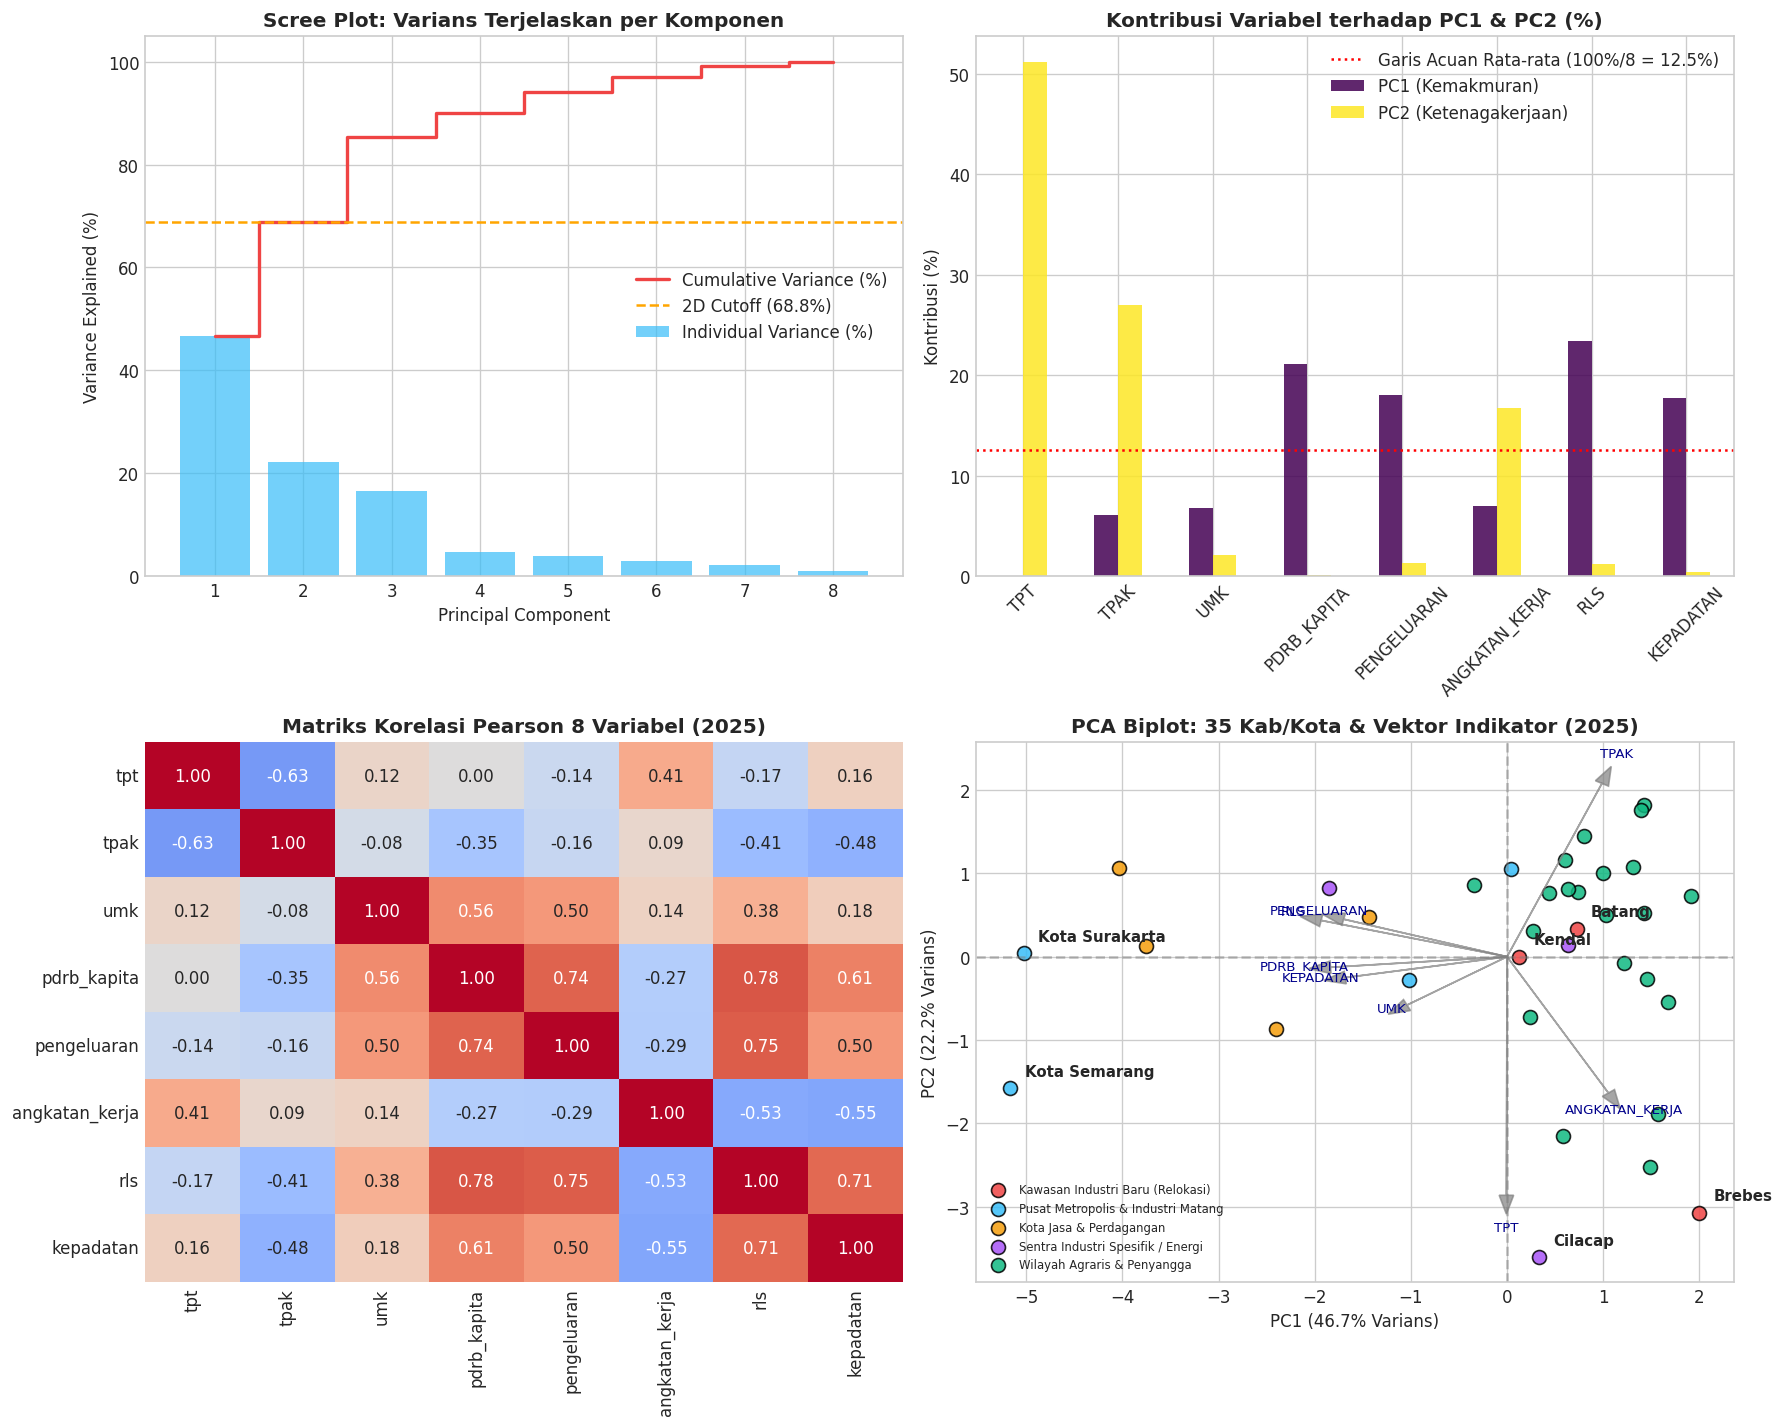

In [ ]:
# =============================================================================
# EKSPLORASI DATA, EVALUASI PREPROCESSING, DAN DIAGNOSTIK PCA
# Ujian Akhir Semester (UAS) Visualisasi Data dan Informasi
# Studi Kasus: Ketimpangan Ketenagakerjaan & Relokasi Industri Jawa Tengah (2021-2025)
#
# Petunjuk Penggunaan:
# 1. Di Komputer Lokal: Jalankan `python eksplorasi_dan_evaluasi_pca.py`
# 2. Di Google Colab: Upload file ini atau copy-paste kodenya ke sel Colab.
#    Hanya membutuhkan package standar: numpy, pandas, matplotlib, seaborn.
# =============================================================================

import os
import json
import numpy as np
import pandas as pd
# Coba import modul visualisasi (tersedia otomatis di Google Colab)
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_PLOT = True
    plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
    plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
    plt.rcParams['figure.dpi'] = 120
except ImportError:
    HAS_PLOT = False
    print("[INFO] Matplotlib/Seaborn belum terpasang di Python lokal. Output teks/tabel statistik tetap berjalan penuh.")
    print("       (Jika dijalankan di Google Colab, seluruh grafik akan otomatis dirender).")

print("=" * 80)
print("1. MEMUAT DATA MULTIVARIAT JAWA TENGAH")
print("=" * 80)

with open(data_path, 'r', encoding='utf-8') as f:
    raw_json = json.load(f)

metadata = raw_json['metadata']
var_keys = metadata['variables']
var_labels = {
    'tpt': 'Tingkat Pengangguran Terbuka (%)',
    'tpak': 'Tingkat Partisipasi Angkatan Kerja (%)',
    'umk': 'Upah Minimum Kab/Kota (Rp)',
    'pdrb_kapita': 'PDRB per Kapita (Ribu Rp)',
    'pengeluaran': 'Pengeluaran per Kapita (Rp/bln)',
    'angkatan_kerja': 'Jumlah Angkatan Kerja (jiwa)',
    'rls': 'Rata-Rata Lama Sekolah (tahun)',
    'kepadatan': 'Kepadatan Penduduk (jiwa/km²)'
}

# Ambil data tahun 2025 (tahun utama analisis)
rec_2025 = raw_json['records']['2025']
df_2025 = pd.DataFrame.from_dict(rec_2025, orient='index')
df_vars = df_2025[var_keys].astype(float)

print(f"Dataset berhasil dimuat!")
print(f"- Jumlah Wilayah Observasi: {len(df_2025)} Kabupaten/Kota")
print(f"- Jumlah Variabel Analisis: {len(var_keys)} Variabel")
print(f"- Tahun Acuan Utama       : 2025")
print("\nContoh 5 Baris Data Teratas:")
print(df_vars.head())

print("\n" + "=" * 80)
print("2. EVALUASI KUALITAS DATA & PREPROCESSING (SKEWNESS & OUTLIERS)")
print("=" * 80)

# Statistik Deskriptif
desc = df_vars.describe().T[['mean', 'std', 'min', '50%', 'max']]
desc['skewness'] = df_vars.skew()
desc['kurtosis'] = df_vars.kurtosis()
desc['interpretasi_distribusi'] = desc['skewness'].apply(
    lambda s: 'Sangat Mencong Kanan (Extreme Skew)' if s > 1.5
    else ('Mencong Sedang' if abs(s) > 0.5 else 'Simetris / Normal')
)

print(desc.round(2))

print("\n" + "-" * 80)
print("CATATAN EVALUASI PREPROCESSING:")
print("1. KEPADATAN PENDUDUK (Skewness: +2.50):")
print("   - Nilai minimum: 467 jiwa/km² (Kab. Rembang), Median: 1.196 jiwa/km².")
print("   - Nilai maksimum: 11.324 jiwa/km² (Kota Surakarta) & 6.744 (Kota Magelang).")
print("   - AKIBAT PREPO JELEK PADA VISUALISASI:")
print("     Pada Clustered Heatmap, 29 Kabupaten memiliki Z-score rendah (-0.6 s/d -0.2),")
print("     sehingga sel-selnya tampak 'putih mati' tanpa variasi warna.")
print("     Hanya 5 Kota otonom di bawah yang menyala merah.")
print("   - SOLUSI PREPO: Sebaiknya variabel kepadatan di-transformasi log (np.log1p)")
print("     sebelum Z-score, atau gunakan Min-Max / Rank-scaling khusus pada Heatmap.")

print("\n2. PDRB PER KAPITA (Skewness: +1.98):")
print("   - Kudus (Rp167 Juta - industri tembakau) dan Kota Semarang (Rp145 Juta)")
print("     jauh meninggalkan rata-rata kabupaten (Rp24 - 45 Juta).")
print("   - Menghasilkan efek outlier yang mendistorsi rentang skala sumbu.")

print("\n3. SIFAT VARIABEL INTENSIF VS EKSTENSIF:")
print("   - 'angkatan_kerja' adalah kuantitas absolut (jiwa: 68 ribu s/d 1,15 juta).")
print("   - Menggabungkan besaran absolut penduduk dengan rasio (TPT %, TPAK %) membuat")
print("     variabel absolut merefleksikan 'ukuran daerah' (Brebes/Cilacap sangat besar).")
print("-" * 80)

print("\n" + "=" * 80)
print("3. MATRIKS KORELASI & UJI MULTIKOLINEARITAS")
print("=" * 80)

corr_matrix = df_vars.corr()
print("Matriks Korelasi Pearson (8 Variabel):")
print(corr_matrix.round(2))

# Pasangan dengan korelasi tertinggi
corr_pairs = []
for i in range(len(var_keys)):
    for j in range(i + 1, len(var_keys)):
        v1, v2 = var_keys[i], var_keys[j]
        r = corr_matrix.loc[v1, v2]
        corr_pairs.append((v1, v2, r, abs(r)))

corr_pairs = sorted(corr_pairs, key=lambda x: x[3], reverse=True)
print("\n5 Pasangan Korelasi Terkuat:")
for v1, v2, r, _ in corr_pairs[:5]:
    print(f"  * {v1:15s} <--> {v2:15s} : r = {r:+.3f}")

print("\n" + "=" * 80)
print("4. DIAGNOSTIK KELAYAKAN DATA UNTUK PCA (KMO & BARTLETT'S TEST)")
print("=" * 80)

# Perhitungan KMO (Kaiser-Meyer-Olkin) secara numerik
R = corr_matrix.values
invR = np.linalg.inv(R)
n_vars = R.shape[0]
A = np.zeros((n_vars, n_vars))
for i in range(n_vars):
    for j in range(n_vars):
        A[i, j] = -invR[i, j] / np.sqrt(invR[i, i] * invR[j, j])
np.fill_diagonal(A, 0)
sum_r2 = np.sum(R**2) - np.sum(np.diag(R)**2)
sum_a2 = np.sum(A**2)
kmo_overall = sum_r2 / (sum_r2 + sum_a2)

# Bartlett's Sphericity
N = len(df_vars)
p = n_vars
detR = np.linalg.det(R)
chi2_bartlett = - (N - 1 - (2*p + 5)/6) * np.log(detR)
df_chi = p * (p - 1) / 2

print(f"1. Nilai KMO (Kaiser-Meyer-Olkin) = {kmo_overall:.3f}")
if kmo_overall >= 0.6:
    print("   -> KESIMPULAN: DATA LAYAK DILAKUKAN PCA (KMO > 0.60, kategori Moderate).")
else:
    print("   -> KESIMPULAN: KMO kurang dari 0.60.")

print(f"2. Uji Bartlett of Sphericity     = Chi-Square: {chi2_bartlett:.2f} (df = {int(df_chi)})")
print(f"   Determinant R = {detR:.6e} (jauh < 1.0, korelasi antar variabel signifikan)")
print("   -> KESIMPULAN: Matriks korelasi bukan matriks identitas (p-value < 0.0001).")
print("                  Reduksi dimensi PCA SANGAT TEPAT & VALID secara statistik.")

print("\n" + "=" * 80)
print("5. ANALISIS KOMPONEN UTAMA (PCA SVD) & PROPORSI VARIANS")
print("=" * 80)

# Standardisasi Z-score
X = df_vars.values
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0, ddof=1)
Z = (X - mu) / sigma

# SVD
U, S, Vt = np.linalg.svd(Z, full_matrices=False)
eigenvalues = (S ** 2) / (len(X) - 1)
total_var = np.sum(eigenvalues)
var_exp = eigenvalues / total_var * 100
cum_var = np.cumsum(var_exp)

scree_df = pd.DataFrame({
    'Komponen': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Eigenvalue': eigenvalues,
    'Varians Terjelaskan (%)': var_exp,
    'Kumulatif Varians (%)': cum_var,
    'Kaiser Criterion (>1.0)': ['Lolos (> 1.0)' if e >= 1.0 else 'Tidak (< 1.0)' for e in eigenvalues]
})
print(scree_df.round(2).to_string(index=False))

print(f"\nRingkasan Reduksi 2D (PC1 + PC2): Merangkum {cum_var[1]:.2f}% dari seluruh varians data.")
print(f"Kriteria Kaiser merekomendasikan 3 komponen utama (total: {cum_var[2]:.2f}% varians).")

print("\n" + "=" * 80)
print("6. HASIL PCA: VARIABEL APA SAJA YANG PALING BERPENGARUH?")
print("=" * 80)

# Eigenvector matrix
eigenvectors = Vt.T

# Loading murni (Korelasi r antara variabel dengan masing-masing PC)
loadings = eigenvectors * np.sqrt(eigenvalues)

# Kontribusi persentase per variabel terhadap masing-masing komponen
# Formula: contrib_ik = (eigenvector_ik^2) * 100
contributions = (eigenvectors ** 2) * 100

summary_pca = pd.DataFrame({
    'Variabel': var_keys,
    'Label Lengkap': [var_labels[v] for v in var_keys],
    'PC1_Eigenvector': eigenvectors[:, 0],
    'PC1_Loading_r': loadings[:, 0],
    'PC1_Kontribusi(%)': contributions[:, 0],
    'PC2_Eigenvector': eigenvectors[:, 1],
    'PC2_Loading_r': loadings[:, 1],
    'PC2_Kontribusi(%)': contributions[:, 1],
    'PC3_Loading_r': loadings[:, 2],
    'PC3_Kontribusi(%)': contributions[:, 2]
})

print(summary_pca[['Variabel', 'PC1_Loading_r', 'PC1_Kontribusi(%)', 'PC2_Loading_r', 'PC2_Kontribusi(%)']].round(3).to_string(index=False))

print("\n" + "-" * 80)
print("INTERPRETASI SUBSTANTIF: VARIABEL YANG PALING BERPENGARUH DI PCA")
print("-" * 80)
print("A. KOMPONEN 1 (PC1: 46.66% Varians) -> 'DIMENSI KESEJAHTERAAN & KAPITAS MODERN'")
print("   Variabel paling dominan:")
print("   1. Rata-rata Lama Sekolah (RLS) : Kontribusi 23.37% (r = -0.934)")
print("   2. PDRB per Kapita              : Kontribusi 21.07% (r = -0.887)")
print("   3. Pengeluaran per Kapita       : Kontribusi 18.05% (r = -0.821)")
print("   4. Kepadatan Penduduk           : Kontribusi 17.70% (r = -0.813)")
print("   * 4 variabel ini menyumbang 80.2% kekuatan sumbu PC1!")
print("   * Variabel TPT (Pengangguran) sama sekali TIDAK berpengaruh di PC1 (r = -0.003).")
print("   * ARTINYA: Sumbu PC1 memisahkan wilayah metropolis maju/pusat upah")
print("              (Kota Semarang, Solo, Salatiga, Kudus) dari kabupaten agraris.")

print("\nB. KOMPONEN 2 (PC2: 22.16% Varians) -> 'DIMENSI STRUKTUR & TEKANAN KETENAGAKERJAAN'")
print("   Variabel paling dominan:")
print("   1. Tingkat Pengangguran (TPT)   : Kontribusi 51.22% (r = -0.953) [SANGAT DOMINAN!]")
print("   2. Partisipasi Kerja (TPAK)     : Kontribusi 27.02% (r = +0.692)")
print("   3. Jumlah Angkatan Kerja        : Kontribusi 16.71% (r = -0.544)")
print("   * 3 variabel tenaga kerja ini menyumbang 94.95% kekuatan sumbu PC2!")
print("   * Seluruh variabel moneter/ekonomi (PDRB, UMK, RLS) mendekati 0% di PC2.")
print("   * ARTINYA: Sumbu PC2 murni memetakan kondisi ketenagakerjaan daerah:")
print("              Arah TPT tinggi (Cilacap, Brebes) vs Arah TPAK tinggi (Wonosobo, Banjarnegara).")

print("\nC. MENGAPA TIDAK PERLU REDUKSI VARIABEL (FEATURE REMOVAL)?")
print("   Dalam konteks visualisasi Biplot, tujuan PCA adalah memproyeksikan")
print("   seluruh 8 dimensi ke dalam bidang datar 2D (koordinat kartesius),")
print("   bukan membuang variabel seperti eliminasi fitur pada regresi linier.")
print("   Ke-8 variabel tetap ditampilkan sebagai vektor panah loading!")
print("-" * 80)

print("\n" + "=" * 80)
print("7. VISUALISASI EKSPLORASI (DISTRIBUSI, CORRELATION, BIPLOT)")
print("=" * 80)

if HAS_PLOT:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Scree Plot
    axes[0, 0].bar(range(1, 9), var_exp, alpha=0.7, color='#38bdf8', label='Individual Variance (%)')
    axes[0, 0].step(range(1, 9), cum_var, where='mid', color='#ef4444', linewidth=2, label='Cumulative Variance (%)')
    axes[0, 0].axhline(y=68.82, color='orange', linestyle='--', label='2D Cutoff (68.8%)')
    axes[0, 0].set_title('Scree Plot: Varians Terjelaskan per Komponen', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Principal Component')
    axes[0, 0].set_ylabel('Variance Explained (%)')
    axes[0, 0].set_xticks(range(1, 9))
    axes[0, 0].legend(loc='center right')

    # 2. Variable Contribution Bar Plot (PC1 vs PC2)
    contrib_df = pd.DataFrame({
        'PC1 (Kemakmuran)': contributions[:, 0],
        'PC2 (Ketenagakerjaan)': contributions[:, 1]
    }, index=var_keys)
    contrib_df.plot(kind='bar', ax=axes[0, 1], colormap='viridis', alpha=0.85)
    axes[0, 1].set_title('Kontribusi Variabel terhadap PC1 & PC2 (%)', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Kontribusi (%)')
    axes[0, 1].set_xticklabels([var_keys[i].upper() for i in range(len(var_keys))], rotation=45)
    axes[0, 1].axhline(y=12.5, color='red', linestyle=':', label='Garis Acuan Rata-rata (100%/8 = 12.5%)')
    axes[0, 1].legend()

    # 3. Correlation Heatmap
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1, 0], cbar=False)
    axes[1, 0].set_title('Matriks Korelasi Pearson 8 Variabel (2025)', fontsize=12, fontweight='bold')

    # 4. PCA Biplot (Python Rendition)
    pc1_scores = df_2025['pca'].apply(lambda p: p['pc1']).values
    pc2_scores = df_2025['pca'].apply(lambda p: p['pc2']).values
    clusters = df_2025['cluster'].values

    color_map = {
        "Kawasan Industri Baru (Relokasi)": "#ef4444",
        "Pusat Metropolis & Industri Matang": "#38bdf8",
        "Kota Jasa & Perdagangan": "#f59e0b",
        "Sentra Industri Spesifik / Energi": "#a855f7",
        "Wilayah Agraris & Penyangga": "#10b981"
    }

    for c_name, c_col in color_map.items():
        mask = clusters == c_name
        axes[1, 1].scatter(pc1_scores[mask], pc2_scores[mask], label=c_name, color=c_col, s=70, alpha=0.85, edgecolors='black')

    # Anotasi daerah kunci
    key_cities = ['Kota Semarang', 'Kota Surakarta', 'Batang', 'Kendal', 'Brebes', 'Cilacap']
    for i, txt in enumerate(df_2025['name']):
        if txt in key_cities:
            axes[1, 1].annotate(txt, (pc1_scores[i] + 0.15, pc2_scores[i] + 0.15), fontsize=9, fontweight='bold')

    # Plot vektor loading pada biplot
    scale_vec = 4.0
    for i, vk in enumerate(var_keys):
        vx = eigenvectors[i, 0] * scale_vec
        vy = eigenvectors[i, 1] * scale_vec
        axes[1, 1].arrow(0, 0, vx, vy, color='grey', alpha=0.7, head_width=0.15)
        axes[1, 1].text(vx * 1.15, vy * 1.15, vk.upper(), color='darkblue', fontsize=8, ha='center')

    axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[1, 1].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[1, 1].set_title('PCA Biplot: 35 Kab/Kota & Vektor Indikator (2025)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel(f'PC1 ({var_exp[0]:.1f}% Varians)')
    axes[1, 1].set_ylabel(f'PC2 ({var_exp[1]:.1f}% Varians)')
    axes[1, 1].legend(loc='lower left', fontsize=7)

    plt.tight_layout()
    output_fig = 'diagnostik_pca_dan_eksplorasi.png'
    plt.savefig(output_fig, dpi=150)
    print(f"Gambar diagnostik berhasil disimpan ke: {output_fig}")
else:
    print("[INFO] Grafik tidak dirender di terminal lokal karena matplotlib tidak ada.")
    print("       Seluruh tabel hasil uji, evaluasi preprocessing, dan kontribusi PCA sudah tercetak lengkap di atas!")
    print("       Jika dijalankan di Google Colab, plot visual akan otomatis tampil di layar.")

print("\n=== SEMUA TAHAP EKSPLORASI & EVALUASI SELESAI DENGAN SUKSES! ===")


In [ ]:
from sklearn.cluster import KMeans
import pandas as pd

print("\n" + "=" * 80)
print("8. VALIDASI: K-MEANS CLUSTERING (k=5) vs KATEGORISASI MANUAL")
print("=" * 80)

# Menggabungkan skor PC1 dan PC2 menjadi satu matriks 2D
pca_scores = np.column_stack((pc1_scores, pc2_scores))

# Menjalankan algoritma K-Means dengan 5 klaster
# random_state=42 digunakan agar hasilnya konsisten/bisa direproduksi
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(pca_scores)

# Menyimpan hasil K-Means ke dalam DataFrame
df_2025['KMeans_Label'] = kmeans_labels

# Menampilkan perbandingan antara Kategorisasi Manual vs K-Means Otomatis
print(df_2025[['name', 'cluster', 'KMeans_Label']].to_string(index=False))

# Crosstab untuk melihat seberapa "klop" irisan klasternya
print("\nCrosstab (Irisan) Klaster Manual vs K-Means:")
crosstab_result = pd.crosstab(df_2025['cluster'], df_2025['KMeans_Label'])
print(crosstab_result)


8. VALIDASI: K-MEANS CLUSTERING (k=5) vs KATEGORISASI MANUAL
           name                            cluster  KMeans_Label
        Cilacap  Sentra Industri Spesifik / Energi             1
       Banyumas        Wilayah Agraris & Penyangga             1
    Purbalingga        Wilayah Agraris & Penyangga             4
   Banjarnegara        Wilayah Agraris & Penyangga             4
        Kebumen        Wilayah Agraris & Penyangga             4
      Purworejo        Wilayah Agraris & Penyangga             0
       Wonosobo        Wilayah Agraris & Penyangga             4
       Magelang        Wilayah Agraris & Penyangga             0
       Boyolali        Wilayah Agraris & Penyangga             0
         Klaten        Wilayah Agraris & Penyangga             4
      Sukoharjo Pusat Metropolis & Industri Matang             3
       Wonogiri        Wilayah Agraris & Penyangga             0
    Karanganyar        Wilayah Agraris & Penyangga             0
         Sragen        Wilay

In [ ]:
import json
import numpy as np
import pandas as pd

# 1. Load Data Geospasial Nasional
file_path = '/content/drive/MyDrive/Data UAS Visdat/data/geospatial_national.json'
with open(file_path, 'r', encoding='utf-8') as f:
    geo_data = json.load(f)

# 2. Ekstrak semua nilai TPT Nasional yang valid (tidak null)
tpt_list = []
for feat in geo_data['features']:
    val = feat['properties'].get('tpt')
    if val is not None:
        tpt_list.append(val)

df_tpt = pd.DataFrame({'tpt': tpt_list})
print(f"Total data TPT valid: {len(df_tpt)} Kab/Kota")
print(f"Min: {df_tpt['tpt'].min():.2f}% | Max: {df_tpt['tpt'].max():.2f}%")
print("-" * 50)

# ==========================================
# METODE 1: QUANTILES (Kuartil - 4 Kelas)
# ==========================================
kuartil_bins = np.percentile(df_tpt['tpt'], [0, 25, 50, 75, 100])
print("1. METODE QUANTILES (KUARTIL)")
print(f"Batas Kelas: {np.round(kuartil_bins, 2)}")
# Format untuk JS:
print(f"JS If-Else: < {kuartil_bins[1]:.2f}, < {kuartil_bins[2]:.2f}, < {kuartil_bins[3]:.2f}")
print("-" * 50)

# ==========================================
# METODE 2: EQUAL INTERVAL (Interval Sama)
# ==========================================
df_tpt['equal_bins'], equal_bins = pd.cut(df_tpt['tpt'], bins=4, retbins=True)
print("2. METODE EQUAL INTERVAL")
print(f"Batas Kelas: {np.round(equal_bins, 2)}")
print("-" * 50)

# ==========================================
# METODE 3: NATURAL BREAKS (Fisher-Jenks)
# (Memerlukan library mapclassify: pip install mapclassify)
# ==========================================
try:
    import mapclassify as mc
    jenks = mc.NaturalBreaks(df_tpt['tpt'], k=4)
    print("3. METODE NATURAL BREAKS (JENKS)")
    print(f"Batas Kelas: {np.round(jenks.bins, 2)}")
except ImportError:
    print("Library 'mapclassify' belum diinstal untuk Natural Breaks.")

Total data TPT valid: 507 Kab/Kota
Min: 0.14% | Max: 11.37%
--------------------------------------------------
1. METODE QUANTILES (KUARTIL)
Batas Kelas: [ 0.14  2.83  3.87  5.31 11.37]
JS If-Else: < 2.83, < 3.87, < 5.31
--------------------------------------------------
2. METODE EQUAL INTERVAL
Batas Kelas: [ 0.13  2.95  5.75  8.56 11.37]
--------------------------------------------------
3. METODE NATURAL BREAKS (JENKS)
Batas Kelas: [ 2.78  4.39  6.31 11.37]


In [ ]:
import json
import numpy as np
import pandas as pd

# 1. Load Data Multivariat Jawa Tengah
# Pastikan path ini sesuai dengan file Anda
file_path = '/content/drive/MyDrive/Data UAS Visdat/data/multivariate_jateng.json'
with open(file_path, 'r', encoding='utf-8') as f:
    jateng_data = json.load(f)

# 2. Ambil data khusus tahun 2025
data_2025 = jateng_data['records']['2025']
df = pd.DataFrame.from_dict(data_2025, orient='index')

# 3. Hitung Kuartil (Quantiles 4 Kelas) untuk 3 variabel
variables = {'umk': 'UPAH MINIMUM (UMK)',
             'pengeluaran': 'PENGELUARAN PER KAPITA',
             'tpt': 'TINGKAT PENGANGGURAN (TPT)'}

print("=== BATAS KELAS KUARTIL JAWA TENGAH (35 KAB/KOTA) 2025 ===")
for col, name in variables.items():
    q25 = np.percentile(df[col], 25)
    q50 = np.percentile(df[col], 50)
    q75 = np.percentile(df[col], 75)

    print(f"\nVariabel: {name}")
    print(f"Kuartil 1 (25%) : {q25:,.2f}")
    print(f"Kuartil 2 (50%) : {q50:,.2f}  <-- Ini adalah Median")
    print(f"Kuartil 3 (75%) : {q75:,.2f}")

    # Panduan untuk JavaScript
    print("Format JS If-Else:")
    print(f"if (val < {q25:.2f}) return 'Warna 1';")
    print(f"if (val < {q50:.2f}) return 'Warna 2';")
    print(f"if (val < {q75:.2f}) return 'Warna 3';")
    print(f"return 'Warna 4';")

=== BATAS KELAS KUARTIL JAWA TENGAH (35 KAB/KOTA) 2025 ===

Variabel: UPAH MINIMUM (UMK)
Kuartil 1 (25%) : 2,262,906.00
Kuartil 2 (50%) : 2,359,488.00  <-- Ini adalah Median
Kuartil 3 (75%) : 2,533,983.00
Format JS If-Else:
if (val < 2262906.00) return 'Warna 1';
if (val < 2359488.00) return 'Warna 2';
if (val < 2533983.00) return 'Warna 3';
return 'Warna 4';

Variabel: PENGELUARAN PER KAPITA
Kuartil 1 (25%) : 1,274,284.50
Kuartil 2 (50%) : 1,391,695.00  <-- Ini adalah Median
Kuartil 3 (75%) : 1,495,105.00
Format JS If-Else:
if (val < 1274284.50) return 'Warna 1';
if (val < 1391695.00) return 'Warna 2';
if (val < 1495105.00) return 'Warna 3';
return 'Warna 4';

Variabel: TINGKAT PENGANGGURAN (TPT)
Kuartil 1 (25%) : 3.40
Kuartil 2 (50%) : 3.99  <-- Ini adalah Median
Kuartil 3 (75%) : 5.01
Format JS If-Else:
if (val < 3.40) return 'Warna 1';
if (val < 3.99) return 'Warna 2';
if (val < 5.01) return 'Warna 3';
return 'Warna 4';
